In [1]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#load dataset
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip install pandas openpyxl scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
#initial inspection
print("Shape of the dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape of the dataset: (541909, 8)

Column Names:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [7]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 5268


In [9]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (536641, 8)


In [10]:
print("Negative Quantity:")
print((df["Quantity"] < 0).sum())

print("\nZero Quantity:")
print((df["Quantity"] == 0).sum())

print("\nNegative Unit Price:")
print((df["UnitPrice"] < 0).sum())

print("\nZero Unit Price:")
print((df["UnitPrice"] == 0).sum())

Negative Quantity:
10587

Zero Quantity:
0

Negative Unit Price:
2

Zero Unit Price:
2510


In [11]:
print("Unique countries:", df["Country"].nunique())

print("\nCustomer IDs:", df["CustomerID"].nunique())

Unique countries: 38

Customer IDs: 4372


In [12]:
df = df.dropna(subset=["CustomerID"])

In [13]:
df = df[df["Quantity"] > 0]

In [14]:
df = df[df["Quantity"] > 0]

In [15]:
print("Shape after cleaning:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

Shape after cleaning: (392732, 8)

Missing Values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [16]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]
df[["Quantity", "UnitPrice", "TotalAmount"]].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [19]:

print(df["InvoiceDate"].dtype)


datetime64[us]


In [20]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [21]:
print(df["InvoiceDate"].dtype)

datetime64[us]


In [23]:
#recency, frequency, monetary value
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Reference Date:", reference_date)
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

Reference Date: 2011-12-10 12:50:00


In [24]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [25]:
#descriptive statistics
print("RFM Descriptive Statistics:")
print(rfm.describe())

RFM Descriptive Statistics:
           Recency    Frequency       Monetary
count  4339.000000  4339.000000    4339.000000
mean     92.518322     4.271952    2048.215924
std     100.009747     7.705493    8984.248352
min       1.000000     1.000000       0.000000
25%      18.000000     1.000000     306.455000
50%      51.000000     2.000000     668.560000
75%     142.000000     5.000000    1660.315000
max     374.000000   210.000000  280206.020000


In [27]:
#average
print("Average Recency:", rfm["Recency"].mean())
print("Average Purchase Frequency:", rfm["Frequency"].mean())
print("Average Monetary Value:", rfm["Monetary"].mean())
average_purchase_value = df["TotalAmount"].sum() / df["InvoiceNo"].nunique()

print("Average Purchase Value:", average_purchase_value)

Average Recency: 92.51832219405392
Average Purchase Frequency: 4.271952062687255
Average Monetary Value: 2048.21592394561
Average Purchase Value: 479.45667317652135


In [28]:
#CLV
customer_lifetime_value = rfm["Monetary"]

print("Average Customer Lifetime Value:", customer_lifetime_value.mean())

Average Customer Lifetime Value: 2048.21592394561


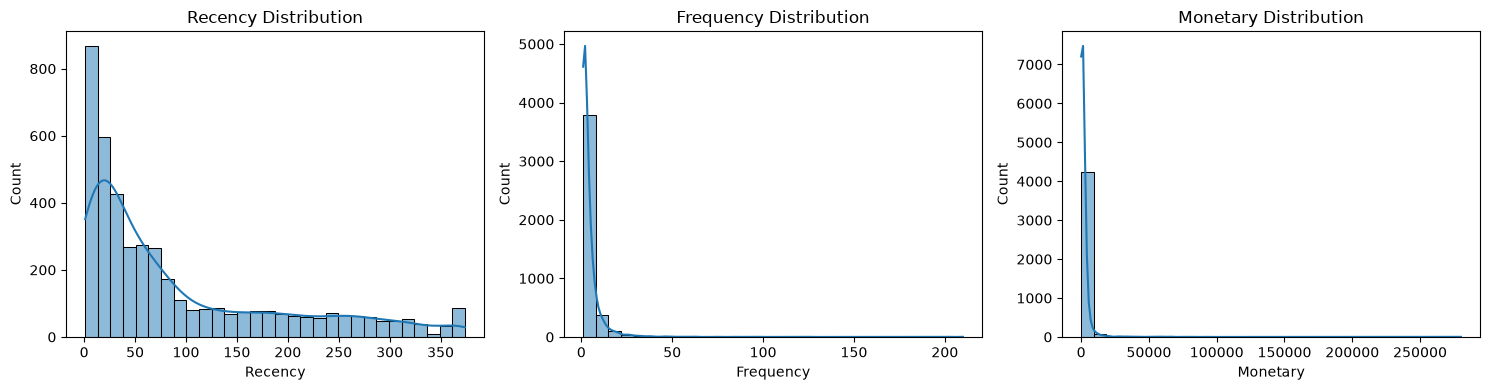

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(rfm["Recency"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(rfm["Frequency"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm["Monetary"], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

In [30]:
#standardisation
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    index=rfm.index,
    columns=rfm.columns
)

rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334858,-0.424675,8.363977
12347.0,-0.905199,0.354080,0.251779
12348.0,-0.175186,-0.035297,-0.027938
12349.0,-0.735196,-0.424675,-0.032357
12350.0,2.174855,-0.424675,-0.190780


<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

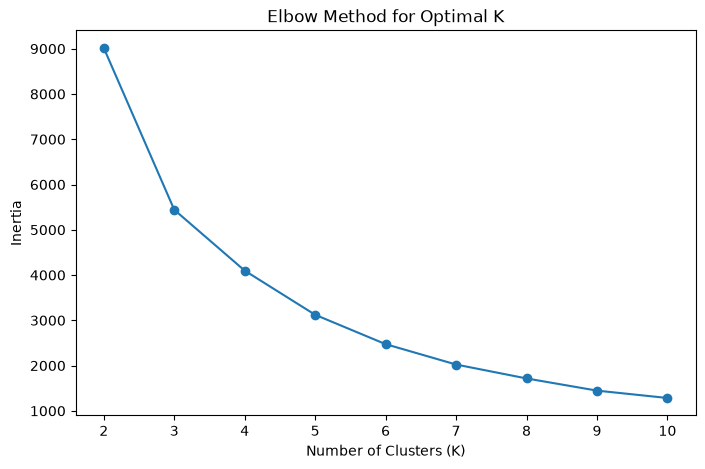

In [32]:
#elbow method
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

    plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.show()

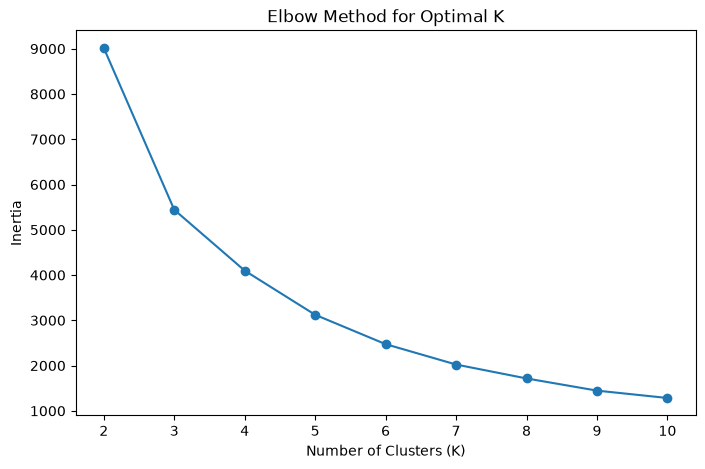

In [34]:
#K means
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

In [35]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,0
12347.0,2,7,4310.00,4
12348.0,75,4,1797.24,4
12349.0,19,1,1757.55,4
12350.0,310,1,334.40,1


In [37]:
#profile the clusters
cluster_profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

print(cluster_profile)
cluster_counts = rfm["Cluster"].value_counts().sort_index()

print(cluster_counts)

            Recency   Frequency       Monetary
Cluster                                       
0         15.238938   20.818584   12349.045177
1        248.661640    1.551367     476.416024
2          6.500000  120.625000   55099.491250
3          7.666667   43.000000  190808.536667
4         44.129361    3.608295    1318.367391
Cluster
0     226
1    1061
2       8
3       6
4    3038
Name: count, dtype: int64


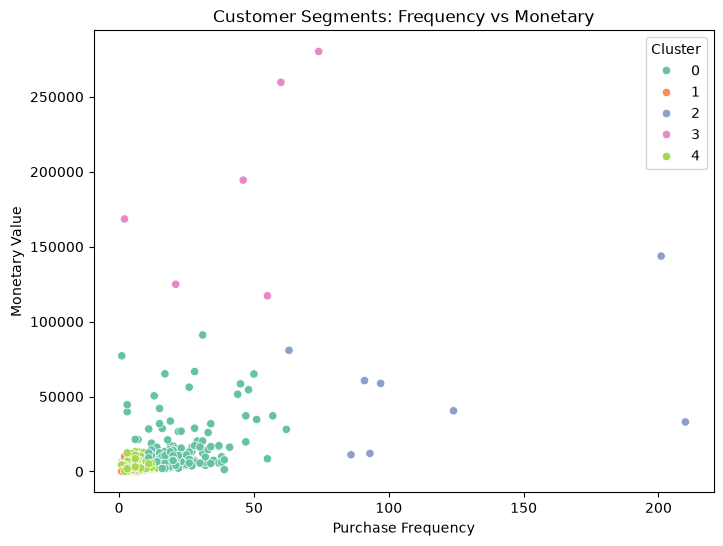

In [38]:
#visualise clusters
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")

plt.show()

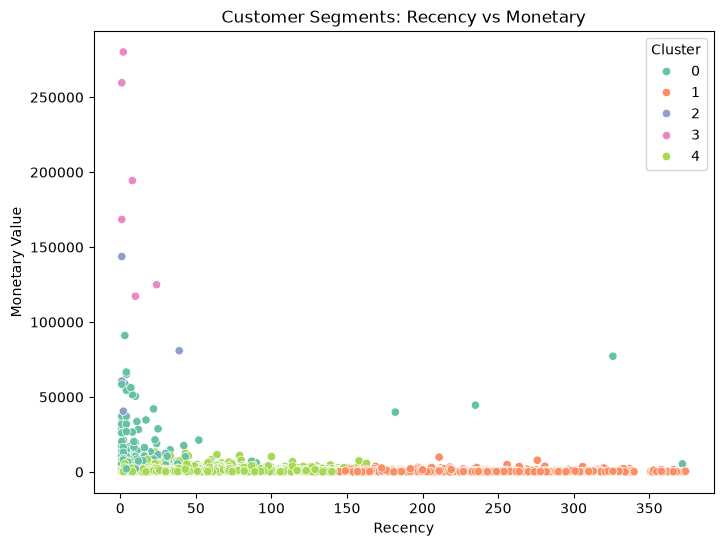

In [39]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segments: Recency vs Monetary")
plt.xlabel("Recency")
plt.ylabel("Monetary Value")

plt.show()

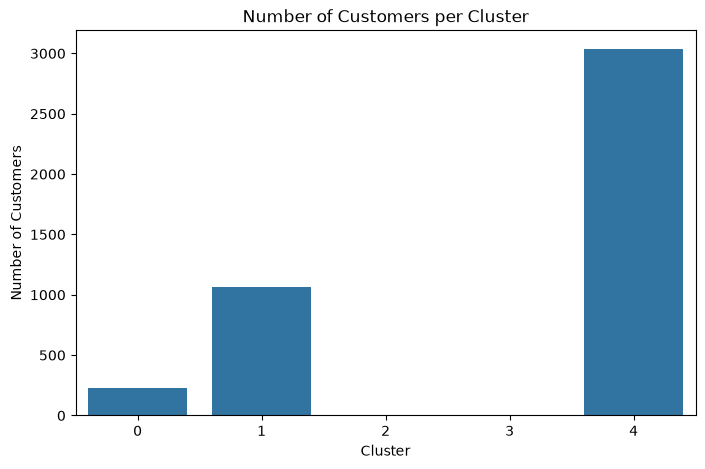

In [40]:
#bar chart
plt.figure(figsize=(8, 5))

sns.countplot(
    data=rfm,
    x="Cluster"
)

plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
#cluster profiling
cluster_profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,15.238938,20.818584,12349.045177
1,248.661640,1.551367,476.416024
2,6.500000,120.625000,55099.491250
3,7.666667,43.000000,190808.536667
4,44.129361,3.608295,1318.367391


In [ ]:

cluster_counts = rfm["Cluster"].value_counts().sort_index()

cluster_counts

Cluster
0     226
1    1061
2       8
3       6
4    3038
Name: count, dtype: int64

In [43]:
cluster_profile = cluster_profile.round(2)

print("Cluster Profile:")
print(cluster_profile)

Cluster Profile:
         Recency  Frequency   Monetary
Cluster                               
0          15.24      20.82   12349.05
1         248.66       1.55     476.42
2           6.50     120.62   55099.49
3           7.67      43.00  190808.54
4          44.13       3.61    1318.37


## Marketing Recommendations

- **Cluster 0 – Regular Valuable Customers:**  
  Encourage repeat purchases through personalised product recommendations, loyalty rewards, and cross-selling offers.

- **Cluster 1 – At-Risk/Lost Customers:**  
  Launch win-back campaigns with personalised discounts, reminders, and special reactivation offers.

- **Cluster 2 – Highly Frequent Loyal Customers:**  
  Reward their frequent purchases with loyalty points, exclusive benefits, subscription offers, and early access to new products.

- **Cluster 3 – VIP/High-Value Customers:**  
  Provide VIP treatment, premium rewards, exclusive products, and personalised offers to retain these highly valuable customers.

- **Cluster 4 – Occasional/Low-Value Customers:**  
  Use targeted promotions, bundle offers, and product recommendations to increase purchase frequency and spending.

## Key Insights

1. K-Means clustering divided customers into five distinct segments based on Recency, Frequency, and Monetary value.
2. Cluster 3 represents the highest-value customers because it has the highest average monetary value.
3. Cluster 2 contains the most frequent purchasers, with an average purchase frequency of 120.62.
4. Cluster 1 represents customers who have not purchased recently and have low purchase frequency and spending, making them an important target for win-back campaigns.
5. Cluster 4 represents occasional low-value customers who could be encouraged to purchase more frequently.
6. RFM-based segmentation can help the business design targeted marketing strategies for different customer groups.

cluster_profile

In [49]:
cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,15.24,20.82,12349.05
1,248.66,1.55,476.42
2,6.50,120.62,55099.49
3,7.67,43.00,190808.54
4,44.13,3.61,1318.37
